In [10]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
import json
import torch.nn as nn
from torchvision.models.resnet import resnet50
import torchvision.transforms as transforms

In [14]:
img = Image.open('./test.JPEG')
img = img.convert('RGB')

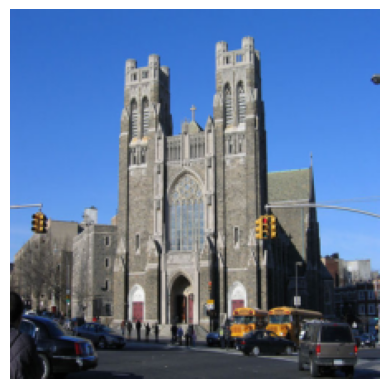

In [15]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])
img = transform(img)
img_hwc = img.permute(1, 2, 0)
plt.imshow(img_hwc)
plt.axis("off")
plt.show()
img = img.unsqueeze(dim=0)

In [16]:
class Normalize(nn.Module):
    def __init__(self, mean, std):
        super(Normalize, self).__init__()
        self.mean = torch.tensor(mean)
        self.std = torch.tensor(std)

    def forward(self, x):
        return (x - self.mean.type_as(x)[None,:,None,None]) / self.std.type_as(x)[None,:,None,None]
imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)
net = resnet50(num_classes=1000, pretrained=True)
model = nn.Sequential(Normalize(mean=imagenet_mean, std=imagenet_std), net)
model.eval()

e:\Anaconda\envs\cv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\Anaconda\envs\cv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Normalize()
  (1): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequen

In [17]:
model.eval()
prob = model(img)
label = torch.argmax(prob.squeeze())
gt_label = label
target_class = json.load(open("imagenet_class_index.json"))[str(label.item())]
print("Natural Image:", target_class[1])

Natural Image: church


# Q1: PGD attack
According to the PPT or the original paper, implement the Projected Gradient Desent (PGD) attack.
https://arxiv.org/abs/1706.06083

In [ ]:
def clamp(X, lower_limit, upper_limit):
    return torch.max(torch.min(X, upper_limit), lower_limit)

def attack_pgd(model, X, y, epsilon=8/255, alpha=2/255, attack_iters=10, restarts=1, lower_limit=torch.tensor([0]), upper_limit=torch.tensor([1])):
    """
    model: Model to attack.
    X: Input image
    y: Class of input image
    epsilon: Budget of PGD attack
    alpha: Step size for PGD attack
    attack_iters: Iterations for PGD attack
    restarts: Restarts for PGD attack
    lower limits: Lower limits for Input Images
    upper limits: Upper limits for Input Images
    """
    ###################################
    # write the code here
    ###################################

    # We will implement the PGD attack in this function.
    # Over T steps, for each step, we will calculate the gradient of the loss with respect to the input image,
    # and then update the image by taking a step in the direction of the gradient .
    # and notice to control the step size by alpha, and also control the total perturbation by epsilon.
    
    # select the best perturbed image among restarts
    best_delta = None
    best_loss = 0

    for _ in range(restarts):

        # initialize the perturbed image by adding a random noise within the epsilon ball
        delta = torch.empty_like(X).uniform_(-epsilon, epsilon)
        delta.requires_grad = True 
        
        for _ in range(attack_iters):
            # zero the gradients
            if delta.grad is not None:
                delta.grad.zero_()

            perturbed_image = X + delta
            
            # forward pass 
            output = model(perturbed_image)
            loss = F.cross_entropy(output, y)
            # backward pass
            loss.backward()

            # update the perturbed image by taking a step in the direction of the gradient
            with torch.no_grad(): # not track gradients for the update step
                delta += alpha * delta.grad.sign()
                perturbed_image = X + delta
                perturbed_image = clamp(perturbed_image, X - epsilon, X + epsilon) 

                delta = perturbed_image - X

                perturbed_image = X + delta
                perturbed_image = clamp(perturbed_image, lower_limit, upper_limit)

                delta = perturbed_image - X
                delta.requires_grad = True 
           
        # evaluate the perturbed image
        with torch.no_grad():
            output = model(perturbed_image)
            loss = F.cross_entropy(output, y) 
            if loss > best_loss:
                best_loss = loss
                best_delta = delta.detach() # share data , not track gradients
    
    return best_delta

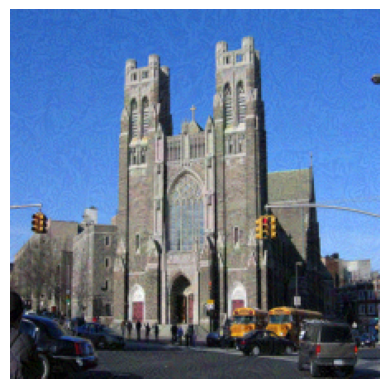

Adversarial Image: motor_scooter


In [34]:
delta = attack_pgd(model,img,gt_label.unsqueeze(dim=0))
adv_img = img+delta
adv_img = adv_img.squeeze()
img_hwc = adv_img.permute(1, 2, 0)
plt.imshow(img_hwc)
plt.axis("off")
plt.show()
prob = model(adv_img)
label = torch.argmax(prob.squeeze())
target_class = json.load(open("imagenet_class_index.json"))[str(label.item())]
print("Adversarial Image:", target_class[1])

# Q2: C&W attack
According to the PPT shown in the class, implement the Carlini  Wagner (C&W) attack.
https://arxiv.org/pdf/1608.04644.pdf?source=post_page

In [ ]:
def attack_cw(model, X, y, cw_kappa=0, cw_iters=10, cw_c=1e-4, cw_lr= 0.01):
    """
    model: Model to attack
    X: Input image
    y: Class of input image
    cw_kappa: kappa for C&W attack
    cw_iters: iteration for the C&W attack
    cw_c: constants for C&W attack
    cw_lr: learning rate for optimizer
    """
    def arctanh(imgs):
        # arctanh function to transform the input image to the unconstrained space
        scaling = torch.clamp(imgs, max=1, min=-1)
        x = 0.999999 * scaling  # to avoid numerical instability
        x = 2*x-1
        # if x = 0 , x = -1, log 0 ? 
        return 0.5*torch.log((1+x)/(1-x)) 

    def scaler(x_atanh):
        # x_atanh is (-inf, inf), we need to scale it back to (0, 1) for the input image
        # tanh function is (-1,1)
        return ((torch.tanh(x_atanh))+1) * 0.5

    def _f(adv_imgs, labels):
        ###################################
        # write the code here
        ###################################
        
        # input is the perturbed image, output is the loss function for the C&W attack
        # forward model
        output = model(adv_imgs)

        # calculate the loss for the C&W attack
        # Part one: stay close to the original image
        l2_loss = F.mse_loss(adv_imgs, X, reduction='sum')

        # Part two: make the model predict the wrong label
        # we want to maximize the difference between the logit of the true label and the logit of the most likely wrong label
        # shape of output is (1, 1000)
        target_logit = output[0, labels]
        # find the maximum logit among the wrong labels 
        wrong_logit = torch.max(output[0, torch.arange(output.shape[1]) != labels])

        # the core idea of the C&W attack is to find the minimum perturbation 
        # that can make the model predict the wrong label 
        # there is no doubt that just rise up the logit of the second largest label 
        # is the most efficient way to make the model predict the wrong label
        # if wrong logit is larger than target logit by kappa, it stops.
        f_loss = torch.clamp(target_logit - wrong_logit + cw_kappa, min=0)

        # combine the two parts of the loss
        loss = l2_loss + cw_c * f_loss
        return loss
        
    model.eval()
    X = X.detach().clone()
    x_arctanh = arctanh(X)
    delta = torch.zeros_like(X)
    delta.detach_()
    delta.requires_grad = True
    optimizer = torch.optim.Adam([delta], lr=cw_lr)
    prev_loss = 1e6
    for step in range(cw_iters):
        optimizer.zero_grad()
        adv_examples = scaler(x_arctanh + delta)
        ###################################
        # write the code here
        ###################################

        # calculate the loss for the C&W attack

        loss = _f(adv_examples, y)
        loss.backward()
        optimizer.step()

        if step % (cw_iters // 10) == 0:
            if loss > prev_loss:
                break
            prev_loss = loss
    adv_imgs = scaler(x_arctanh + delta).detach()
    return adv_imgs

The class of y is tensor([497])
The shape of output is torch.Size([1, 1000])
The class of y is tensor([497])
The shape of output is torch.Size([1, 1000])


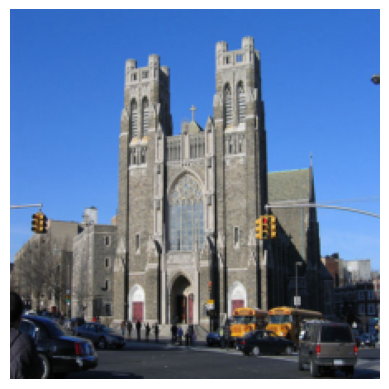

Adversarial Image: bell_cote


In [43]:
adv_img = attack_cw(model,img,gt_label.unsqueeze(dim=0),cw_iters=10)
adv_img = adv_img.squeeze()
img_hwc = adv_img.permute(1, 2, 0)
plt.imshow(img_hwc)
plt.axis("off")
plt.show()
prob = model(adv_img)
label = torch.argmax(prob.squeeze())
target_class = json.load(open("imagenet_class_index.json"))[str(label.item())]
print("Adversarial Image:", target_class[1])